# лабораторная работа 2

надо выбрат функцию, не интегрируемую по Риману, реализовать два различных способа оснащения одного и того же разбиения и показать, что получаемые интегральные суммы существенно различаются

## 1. функция Дирихле

рассмотрим на отрезке $[0,1]$ функцию

$$
f(x) =
\begin{cases}
1, & x \in \mathbb{Q} \\
0, & x \notin \mathbb{Q}
\end{cases}
$$

эта функция не интегрируема по Риману: на любом подотрезке найдутся и рациональные, и иррациональные точки, поэтому выбор оснащающих точек $\xi_i$ полностью определяет значение интегральной суммы

в коде рациональные числа представляются точными объектами `fractions.Fraction` (точная арифметика), а иррациональные точки строятся явно как $a + (\sqrt{2}-1)\cdot(b-a)$ — это число иррационально, поскольку $\sqrt 2$ иррационально, а $a,\,b-a$ — рациональны (при $b\neq a$). представление через `float` вносит погрешность, но не меняет природы числа, поэтому функция `f` определяется не приближённым тестом "похоже на рациональное", а типом объекта: `Fraction` — рациональное число, обычный `float`, полученный описанной конструкцией — иррациональное

In [ ]:
%matplotlib inline
from fractions import Fraction
import math
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
# функция дирихле: 1, если x - рациональное число (Fraction), 0 - если иррациональное
def f_dirichlet(x):
    return 1 if isinstance(x, Fraction) else 0


## 2. разбиение и два способа оснащения

строим равномерное разбиение $[0,1]$ на $n$ частей с точными рациональными узлами $x_i = i/n$

* **оснащение 1** — в каждом подотрезке $\xi_i$ берётся середина, представленная как точное рациональное число (`Fraction`) $\Rightarrow f(\xi_i)=1$ для всех $i$
* **оснащение 2** — в каждом подотрезке $\xi_i$ берётся иррациональная точка $a_i + (\sqrt2-1)(b_i-a_i)$, заведомо лежащая строго внутри $(a_i,b_i)$ $\Rightarrow f(\xi_i)=0$ для всех $i$

In [2]:
# равномерное разбиение [0,1] на n частей точными рациональными узлами
def partition(n):
    return [Fraction(i, n) for i in range(n + 1)]


# оснащение 1: середины подотрезков как точные рациональные числа
def tags_rational(points):
    return [(points[i] + points[i + 1]) / 2 for i in range(len(points) - 1)]


# оснащение 2: иррациональные точки внутри каждого подотрезка
def tags_irrational(points):
    irr = math.sqrt(2) - 1  # иррациональное число в интервале (0, 1)
    tags = []
    for i in range(len(points) - 1):
        a, b = points[i], points[i + 1]
        t = float(a) + float(b - a) * irr
        tags.append(t)
    return tags


# интегральная сумма для заданного разбиения points и оснащения tags
def riemann_sum(points, tags, f):
    return sum(f(tags[i]) * float(points[i + 1] - points[i]) for i in range(len(tags)))


## 3. сравнение интегральных сумм при измельчении разбиения

In [ ]:
ns = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
rows = []
for n in ns:
    pts = partition(n)
    s1 = riemann_sum(pts, tags_rational(pts), f_dirichlet)
    s2 = riemann_sum(pts, tags_irrational(pts), f_dirichlet)
    rows.append({"n": n, "S1 (оснащение рациональными точками)": s1,
                 "S2 (оснащение иррациональными точками)": s2,
                 "|S1 - S2|": abs(s1 - s2)})
df = pd.DataFrame(rows)
df


,n,S1 (оснащение рациональными точками),S2 (оснащение иррациональными точками),|S1 - S2|
0,2,1.0,0.0,1.0
1,4,1.0,0.0,1.0
2,8,1.0,0.0,1.0
3,16,1.0,0.0,1.0
4,32,1.0,0.0,1.0
5,64,1.0,0.0,1.0
6,128,1.0,0.0,1.0
7,256,1.0,0.0,1.0
8,512,1.0,0.0,1.0
9,1024,1.0,0.0,1.0


видно, что $S_1 \equiv 1$ (сумма длин всех подотрезков, умноженных на $1$) и $S_2 \equiv 0$ для **любого** $n$ поэтому разность $|S_1-S_2|\equiv 1$ не зависит от мелкости разбиения и, в частности, не стремится к нулю при $n\to\infty$ — предел интегральных сумм зависит от выбора оснащающих точек, значит функция дирихле не интегрируема по риману на $[0,1]$

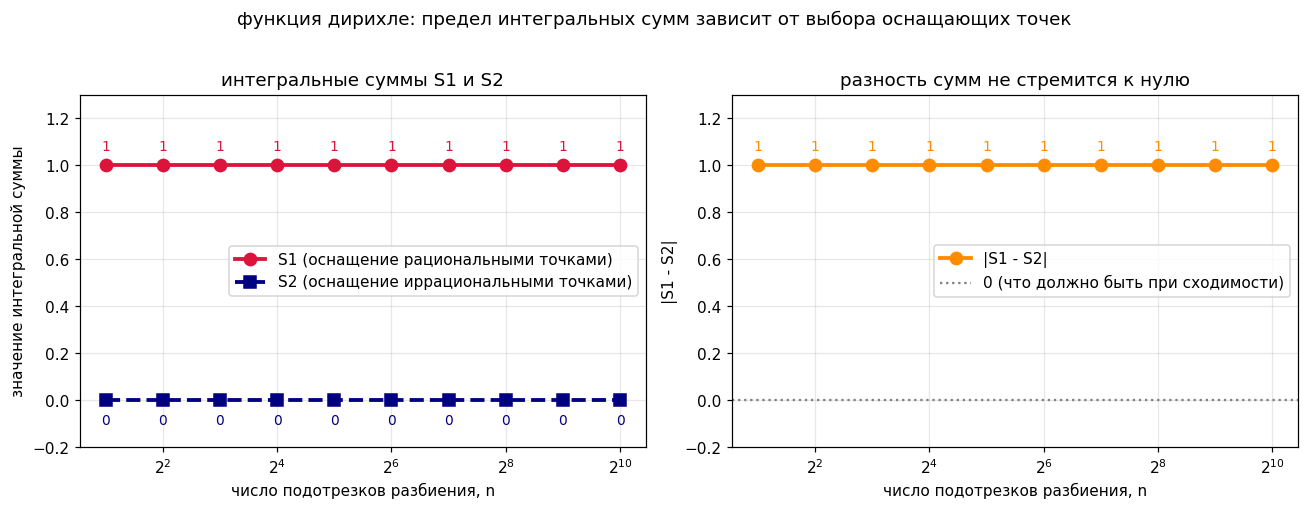

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(df["n"], df["S1 (оснащение рациональными точками)"], marker="o", markersize=8,
        color="crimson", linewidth=2.5, label="S1 (оснащение рациональными точками)")
ax.plot(df["n"], df["S2 (оснащение иррациональными точками)"], marker="s", markersize=8,
        color="navy", linewidth=2.5, linestyle="--", label="S2 (оснащение иррациональными точками)")
for x, y in zip(df["n"], df["S1 (оснащение рациональными точками)"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", color="crimson", fontsize=9)
for x, y in zip(df["n"], df["S2 (оснащение иррациональными точками)"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, -16), ha="center", color="navy", fontsize=9)
ax.set_xscale("log", base=2)
ax.set_xlabel("число подотрезков разбиения, n")
ax.set_ylabel("значение интегральной суммы")
ax.set_title("интегральные суммы S1 и S2")
ax.set_ylim(-0.2, 1.3)
ax.legend(loc="center right")
ax.grid(alpha=0.3)
ax2 = axes[1]
ax2.plot(df["n"], df["|S1 - S2|"], marker="o", markersize=8, color="darkorange", linewidth=2.5, label="|S1 - S2|")
ax2.axhline(0, color="gray", linestyle=":", linewidth=1.5, label="0 (что должно быть при сходимости)")
for x, y in zip(df["n"], df["|S1 - S2|"]):
    ax2.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", color="darkorange", fontsize=9)
ax2.set_xscale("log", base=2)
ax2.set_xlabel("число подотрезков разбиения, n")
ax2.set_ylabel("|S1 - S2|")
ax2.set_title("разность сумм не стремится к нулю")
ax2.set_ylim(-0.2, 1.3)
ax2.legend(loc="center right")
ax2.grid(alpha=0.3)
fig.suptitle("функция дирихле: предел интегральных сумм зависит от выбора оснащающих точек", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


## 4. ещё одна неинтегрируемая по Риману функция: индикатор двоично-рациональных точек

рассмотрим модификацию функции дирихле:

$$
g(x) =
\begin{cases}
1, & x = \dfrac{k}{2^m},\ k,m\in\mathbb{Z},\ m\ge 0 \ (\text{двоично-рациональное число}) \\
0, & \text{иначе}
\end{cases}
$$

двоично-рациональные числа всюду плотны на $[0,1]$ (как и все рациональные), но их множество имеет меру нуль в любом подотрезке найдётся и двоично-рациональная, и не двоично-рациональная (в т.ч. иррациональная) точка, поэтому $g$ обладает тем же эффектом -интегральная сумма зависит от выбора оснащения

* **оснащение 1** — $\xi_i$ выбирается как двоично-рациональная точка строго внутри подотрезка $\Rightarrow g(\xi_i) = 1$
* **оснащение 2** — $\xi_i$ — та же иррациональная точка, что и выше $\Rightarrow g(\xi_i) = 0$ (иррациональное число не является двоично-рациональным)

In [ ]:
# проверяет, является ли точное рациональное число (Fraction) двоично рациональным
# т.е. имеет ли его знаменатель в несократимом виде вид степени двойки
def is_dyadic(x):
    if not isinstance(x, Fraction):
        return False
    den = x.denominator
    while den % 2 == 0:
        den //= 2
    return den == 1


# индикатор двоично-рациональных чисел: 1, если x - двоично-рациональное, иначе 0
def g_dyadic(x):
    return 1 if is_dyadic(x) else 0


# находит точное двоично-рациональное число, лежащее строго внутри интервала (a, b)
def dyadic_in(a, b):
    m = 1
    while True:
        denom = 2 ** m
        k = math.floor(a * denom) + 1
        candidate = Fraction(k, denom)
        if a < candidate < b:
            return candidate
        m += 1


# оснащение 1 для g: двоично-рациональная точка в каждом подотрезке
def tags_dyadic(points):
    return [dyadic_in(points[i], points[i + 1]) for i in range(len(points) - 1)]


In [6]:
rows_g = []
for n in ns:
    pts = partition(n)
    s1 = riemann_sum(pts, tags_dyadic(pts), g_dyadic)
    s2 = riemann_sum(pts, tags_irrational(pts), g_dyadic)
    rows_g.append({"n": n, "S1 (двоично-рациональное оснащение)": s1,
                    "S2 (иррациональное оснащение)": s2,
                    "|S1 - S2|": abs(s1 - s2)})

df_g = pd.DataFrame(rows_g)
df_g


,n,S1 (двоично-рациональное оснащение),S2 (иррациональное оснащение),|S1 - S2|
0,2,1.0,0.0,1.0
1,4,1.0,0.0,1.0
2,8,1.0,0.0,1.0
3,16,1.0,0.0,1.0
4,32,1.0,0.0,1.0
5,64,1.0,0.0,1.0
6,128,1.0,0.0,1.0
7,256,1.0,0.0,1.0
8,512,1.0,0.0,1.0
9,1024,1.0,0.0,1.0


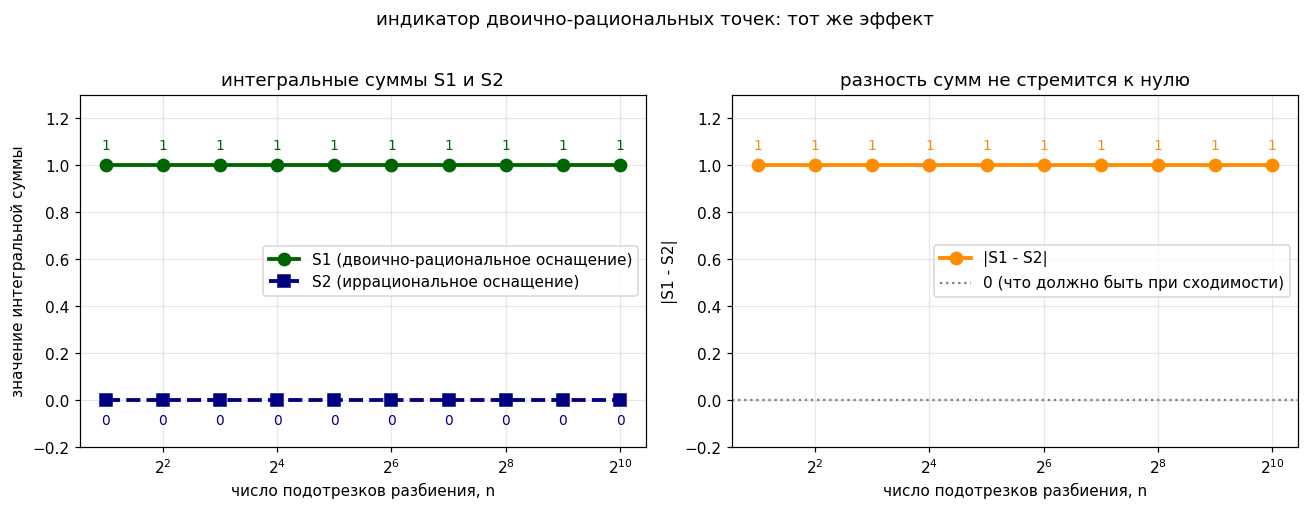

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(df_g["n"], df_g["S1 (двоично-рациональное оснащение)"], marker="o", markersize=8,
        color="darkgreen", linewidth=2.5, label="S1 (двоично-рациональное оснащение)")
ax.plot(df_g["n"], df_g["S2 (иррациональное оснащение)"], marker="s", markersize=8,
        color="navy", linewidth=2.5, linestyle="--", label="S2 (иррациональное оснащение)")
for x, y in zip(df_g["n"], df_g["S1 (двоично-рациональное оснащение)"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", color="darkgreen", fontsize=9)
for x, y in zip(df_g["n"], df_g["S2 (иррациональное оснащение)"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, -16), ha="center", color="navy", fontsize=9)
ax.set_xscale("log", base=2)
ax.set_xlabel("число подотрезков разбиения, n")
ax.set_ylabel("значение интегральной суммы")
ax.set_title("интегральные суммы S1 и S2")
ax.set_ylim(-0.2, 1.3)
ax.legend(loc="center right")
ax.grid(alpha=0.3)
ax2 = axes[1]
ax2.plot(df_g["n"], df_g["|S1 - S2|"], marker="o", markersize=8, color="darkorange", linewidth=2.5, label="|S1 - S2|")
ax2.axhline(0, color="gray", linestyle=":", linewidth=1.5, label="0 (что должно быть при сходимости)")
for x, y in zip(df_g["n"], df_g["|S1 - S2|"]):
    ax2.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", color="darkorange", fontsize=9)
ax2.set_xscale("log", base=2)
ax2.set_xlabel("число подотрезков разбиения, n")
ax2.set_ylabel("|S1 - S2|")
ax2.set_title("разность сумм не стремится к нулю")
ax2.set_ylim(-0.2, 1.3)
ax2.legend(loc="center right")
ax2.grid(alpha=0.3)
fig.suptitle("индикатор двоично-рациональных точек: тот же эффект", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


## 5. вывод

для обеих рассмотренных функций (дирихле и индикатора двоично-рациональных точек) интегральная сумма принимает одно из двух постоянных значений ($1$ или $0$) в зависимости **исключительно** от того, какой тип точек (рациональные/двоично-рациональные или иррациональные) выбран в качестве оснащающих, и это никак не зависит от мелкости разбиения $n$. разность $|S_1-S_2|\equiv 1$ не стремится к $0$ при $n\to\infty$, поэтому предел интегральных сумм не существует независимо от выбора $\xi_i$ — обе функции **не интегрируемы по риману** на $[0,1]$ (хотя обе ограничены и, что характерно, интегрируемы по лебегу с интегралом $0$, так как множества рациональных и двоично-рациональных чисел имеют меру нуль)